# Walmart Store Sales Forecasting — PatchTST


In [1]:
%pip install -q seaborn mlflow dagshub wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 91.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
if not os.path.exists("preprocessing.py"):
    !wget -q https://raw.githubusercontent.com/romaxod/ML-FINAL/main/preprocessing.py \
            https://raw.githubusercontent.com/romaxod/ML-FINAL/main/evaluation.py \
            https://raw.githubusercontent.com/romaxod/ML-FINAL/main/models.py

In [3]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow


import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py", "models.py"]

ARCH = "PatchTST"


In [4]:

import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=40cad5c8-ea10-41b0-afe3-344c56073128&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e0dc13a99f50c5717c9563f953b605dca0767fb762b7d9052a1ec425bf956302




Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: PatchTST_Training


In [5]:

import wandb

WANDB_PROJECT = "walmart-final"
WANDB_ENTITY  = "rkvit23-free-university-of-tbilisi-"

wandb.login()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rkvit23 (rkvit23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# Only relevant on Kaggle - local/Colab already resolve data via CANDIDATE_DIRS.
if os.path.exists("/kaggle/input"):
    !ls /kaggle/input/competitions/
    prep.CANDIDATE_DIRS.append("/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/")



walmart-recruiting-store-sales-forecasting


In [7]:

train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()      # 39 weeks

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)


train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


In [8]:

features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")


🏃 View run PatchTST_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/5161a0b815594dd4b0f97de706e01f7b
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3
cleaning done


## Windowing (global model)


In [9]:
dm = prep.build_series_matrix(train_raw, HORIZON)
Y, Ys, scale = dm.Y, dm.Ys, dm.scale
series_idx, all_dates, T = dm.series_idx, dm.all_dates, dm.T
w_week, S = dm.w_week, dm.n_series
VAL_CUT, val_dates = dm.val_cut, dm.val_dates
val_actual = train_raw[train_raw.Date >= val_dates[0]][
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()

with mlflow.start_run(run_name=f"{ARCH}_Windowing"):
    mlflow.log_params({
        "fill_missing_weeks": "0 (dept not trading)",
        "negatives": "clipped to 0",
        "scaling": "per-series mean, floor=1.0",
        "strategy": "global model, direct multi-horizon H=39",
        "val": "last 39 weeks of train",
    })
    mlflow.log_metrics({"n_series": S, "n_weeks": T, "obs_fraction": dm.obs_frac})
print(f"matrix {Y.shape} | observed fraction {dm.obs_frac:.3f} | VAL_CUT={VAL_CUT}")


🏃 View run PatchTST_Windowing at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/eef33d57fa8c44049c993b9d78aed717
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3
matrix (3331, 143) | observed fraction 0.885 | VAL_CUT=104


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

def make_windows(L, H, t_max):
    """Sliding windows over all series: input [t-L, t) -> target [t, t+H), t <= t_max-H."""
    xs, ys, ws = [], [], []
    for t in range(L, t_max - H + 1):
        xs.append(Ys[:, t - L:t])
        ys.append(Ys[:, t:t + H])
        ws.append(np.tile(w_week[t:t + H], (S, 1)))
    X = np.concatenate(xs); Yt = np.concatenate(ys); W = np.concatenate(ws)
    SC = np.tile(scale[:, 0], t_max - H + 1 - L)
    keep = X.sum(axis=1) > 0
    return (torch.tensor(X[keep]), torch.tensor(Yt[keep]),
            torch.tensor(W[keep]), torch.tensor(SC[keep]))

def forecast_matrix(model, L, t_end):
    """Forecast all series (S, H) in dollars, input = last L weeks before t_end."""
    model.eval()
    with torch.no_grad():
        x = torch.tensor(Ys[:, t_end - L:t_end]).to(DEVICE)
        return model(x).cpu().numpy() * scale

def val_wmae_of(model, L):
    pred = forecast_matrix(model, L, VAL_CUT)
    dfp = pd.DataFrame(pred, index=series_idx, columns=val_dates)
    dfp.columns.name = "Date"
    long = dfp.stack().rename("pred").reset_index()
    m = val_actual.merge(long, on=["Store", "Dept", "Date"], how="left")
    m["pred"] = m["pred"].fillna(0).clip(lower=0)
    return wmae(m.Weekly_Sales, m.pred, m.IsHoliday), m

def train_model(model, cfg, run_name, log_wandb=True, init_wandb=True,
                t_max=None, epochs=None, eval_val=True):
    """Train one config: weighted-L1 loss, early stopping on val WMAE,
    logging to BOTH MLflow and W&B."""
    t_max = t_max or VAL_CUT
    X, Yt, W, SC = make_windows(cfg["L"], HORIZON, t_max)
    dl_ = DataLoader(TensorDataset(X, Yt, W, SC),
                     batch_size=cfg.get("batch", 1024), shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.get("lr", 1e-3),
                           weight_decay=cfg.get("weight_decay", 0.0))
    n_epochs = epochs or cfg.get("epochs", 40)
    patience = cfg.get("patience", 6)
    best_v, best_ep, best_state, bad = float("inf"), 0, None, 0
    hist = []
    if log_wandb and init_wandb:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name=run_name,
                   group=f"{ARCH}_Training", config=cfg, reinit=True)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({k: str(v) for k, v in cfg.items()})
        n_par = sum(p.numel() for p in model.parameters())
        mlflow.log_param("n_parameters", n_par)
        for ep in range(1, n_epochs + 1):
            model.train(); tot, nb = 0.0, 0
            for xb, yb, wb, scb in dl_:
                xb, yb, wb, scb = [a.to(DEVICE) for a in (xb, yb, wb, scb)]
                pred = model(xb)
                if cfg.get("scale_weighted_loss"):
                    # weight by series scale -> loss matches dollar WMAE
                    w_eff = wb * (scb / scb.mean()).unsqueeze(1)
                else:
                    w_eff = wb
                loss = (w_eff * (pred - yb).abs()).mean()
                opt.zero_grad(); loss.backward(); opt.step()
                tot += loss.item(); nb += 1
            row = {"epoch": ep, "train_loss": tot / nb}
            if eval_val:
                vw, _ = val_wmae_of(model, cfg["L"])
                row["val_wmae"] = vw
                if vw < best_v - 1e-6:
                    best_v, best_ep, bad = vw, ep, 0
                    best_state = {k: v.detach().cpu().clone()
                                  for k, v in model.state_dict().items()}
                else:
                    bad += 1
            mlflow.log_metrics({k: v for k, v in row.items() if k != "epoch"}, step=ep)
            if log_wandb:
                wandb.log(row)
            hist.append(row)
            if eval_val and bad >= patience:
                print(f"  early stop @ epoch {ep} (best {best_v:,.1f} @ {best_ep})")
                break
        if eval_val and best_state is not None:
            model.load_state_dict(best_state)
            mlflow.log_metric("best_val_wmae", best_v)
            mlflow.log_metric("best_epoch", best_ep)
        if log_wandb:
            if eval_val:
                wandb.summary["best_val_wmae"] = best_v
                wandb.summary["best_epoch"] = best_ep
                wandb.summary["n_parameters"] = n_par
            if init_wandb:
                wandb.finish()
    return best_v, best_ep, hist


device: cuda


## Model implementation and configurations

In [11]:
from models import PatchTST, build_patchtst_model as build_model, \
    TorchForecastPipeline

CONFIGS = [
    dict(name="p8_d64_l2",      L=52, patch_len=8, stride=4, d_model=64, nhead=4,
         n_layers=2, dropout=0.1, lr=1e-3),
    dict(name="p8_d128_l3",     L=52, patch_len=8, stride=4, d_model=128, nhead=8,
         n_layers=3, dropout=0.2, lr=5e-4),
    dict(name="p4_d64_l2",      L=52, patch_len=4, stride=2, d_model=64, nhead=4,
         n_layers=2, dropout=0.1, lr=1e-3),
    dict(name="p8_d128_norevin", L=52, patch_len=8, stride=4, d_model=128, nhead=8,
         n_layers=3, dropout=0.2, lr=5e-4, revin=False),
    dict(name="p13_L65_d128",   L=65, patch_len=13, stride=6, d_model=128, nhead=8,
         n_layers=3, dropout=0.2, lr=5e-4),
    dict(name="p8_d128_scaleW", L=52, patch_len=8, stride=4, d_model=128, nhead=8,
         n_layers=3, dropout=0.2, lr=5e-4, scale_weighted_loss=True),
]

SWEEP_SPACE = {
    "d_model": {"values": [64, 128]},
    "n_layers": {"values": [2, 3, 4]},
    "dropout": {"distribution": "uniform", "min": 0.0, "max": 0.4},
    "patch_len": {"values": [4, 8]},
    "lr": {"distribution": "log_uniform_values", "min": 1e-4, "max": 3e-3},
}

def cfg_from_sweep(wc):
    return dict(L=52, patch_len=wc["patch_len"], stride=max(wc["patch_len"] // 2, 1),
                d_model=wc["d_model"], nhead=4 if wc["d_model"] == 64 else 8,
                n_layers=wc["n_layers"], dropout=wc["dropout"], lr=wc["lr"])


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [12]:

_m = build_model(CONFIGS[0], HORIZON).to(DEVICE)
_x = torch.rand(8, CONFIGS[0]["L"], device=DEVICE)
_out = _m(_x)
assert _out.shape == (8, HORIZON), _out.shape
_out.abs().mean().backward()
_ok = sum(int(p.grad is not None and torch.isfinite(p.grad).all())
          for p in _m.parameters() if p.requires_grad)
print(f"forward OK {tuple(_out.shape)} | tensors with finite grads: {_ok}")
del _m, _x, _out


forward OK (8, 39) | tensors with finite grads: 29


## Comparing configurations


In [13]:
RESULTS, HISTORIES = {}, {}
best_overall = {"wmae": float("inf"), "cfg": None, "epochs": None}
BEST_MODEL = None

for cfg in CONFIGS:
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = build_model(cfg, HORIZON).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"\n=== {cfg['name']}  ({n_par:,} params) ===")
    v, ep, hist = train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}")
    RESULTS[cfg["name"]] = {"val_wmae": round(v, 1), "best_epoch": ep, "params": n_par}
    HISTORIES[cfg["name"]] = hist
    if v < best_overall["wmae"]:
        best_overall = {"wmae": v, "cfg": cfg, "epochs": ep}
        BEST_MODEL = model

res_df = pd.DataFrame(RESULTS).T.sort_values("val_wmae")
print("\n", res_df)
BEST_CFG, BEST_EPOCHS = best_overall["cfg"], max(best_overall["epochs"], 1)
print("\nbest config:", BEST_CFG["name"], "| val WMAE:", round(best_overall["wmae"], 1))



=== p8_d64_l2  (98,279 params) ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  early stop @ epoch 20 (best 1,689.1 @ 14)


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_wmae,█▆▆▅▄▃▃▅▂▂▃▃▂▁▂▃▂▂▂▁
best_epoch,14
best_val_wmae,1689.13739
epoch,20
n_parameters,98279
train_loss,0.32032
val_wmae,1704.97463


🏃 View run PatchTST_p8_d64_l2 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/68a284efab494d1b9a736c308276a05a
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3

=== p8_d128_l3  (460,071 params) ===


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▅▄▅▄▄▄▃▃▂▃▂▂▂▂▂▂▂▁▂▂▂▂▂▂▁▁▁▁▂▂▁▁
val_wmae,█▆▆▄▅▄▃▃▂▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▂▁▂▁▂▂▁▁
best_epoch,27
best_val_wmae,2010.80996
epoch,33
n_parameters,445351
train_loss,0.43335
val_wmae,2039.46358


🏃 View run PatchTST_p13_L65_d128 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/23ebf5552879445db4d8be45b32844b1
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3

=== p8_d128_scaleW  (460,071 params) ===


  early stop @ epoch 14 (best 1,624.0 @ 8)


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁
val_wmae,█▄▄▅▂▂▃▁▂▆▃▁▂▂
best_epoch,8
best_val_wmae,1623.97029
epoch,14
n_parameters,460071
train_loss,0.11785
val_wmae,1651.20353


🏃 View run PatchTST_p8_d128_scaleW at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/c08040dfdd4a409c9399155e67268784
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3

                  val_wmae  best_epoch    params
p8_d128_scaleW     1624.0         8.0  460071.0
p8_d128_norevin    1654.1        28.0  460071.0
p8_d128_l3         1663.2        20.0  460071.0
p8_d64_l2          1689.1        14.0   98279.0
p4_d64_l2          1703.5        12.0  131303.0
p13_L65_d128       2010.8        27.0  445351.0

best config: p8_d128_scaleW | val WMAE: 1624.0


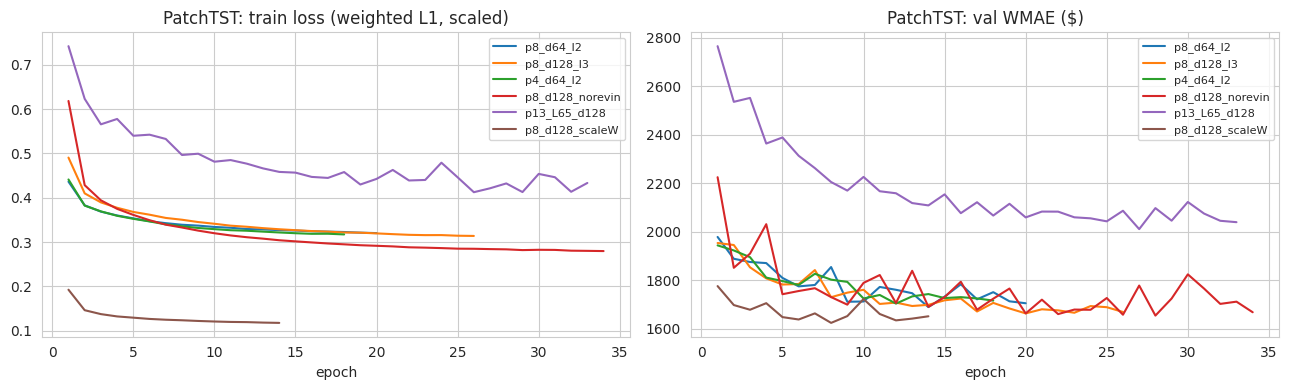

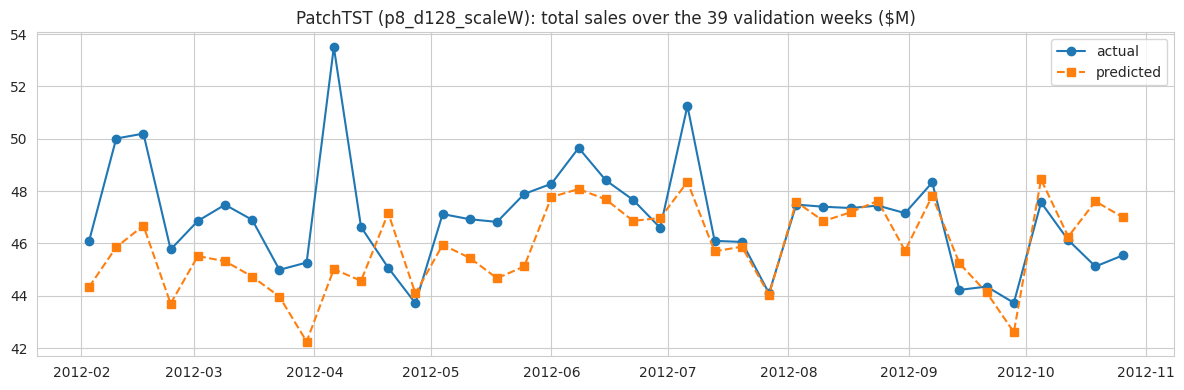

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in HISTORIES.items():
    h = pd.DataFrame(hist)
    axes[0].plot(h.epoch, h.train_loss, label=name)
    if "val_wmae" in h:
        axes[1].plot(h.epoch, h.val_wmae, label=name)
axes[0].set_title(f"{ARCH}: train loss (weighted L1, scaled)")
axes[1].set_title(f"{ARCH}: val WMAE ($)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_curves.png", dpi=120); plt.show()

_, mval = val_wmae_of(BEST_MODEL, BEST_CFG["L"])
fig, ax = plt.subplots(figsize=(12, 4))
a = mval.groupby("Date").Weekly_Sales.sum() / 1e6
p = mval.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({BEST_CFG['name']}): total sales over the 39 validation weeks ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()


### W&B sweep

In [15]:

RUN_SWEEP = True
SWEEP_COUNT = 8

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        {"method": "bayes",
         "metric": {"name": "best_val_wmae", "goal": "minimize"},
         "parameters": SWEEP_SPACE},
        project=WANDB_PROJECT, entity=WANDB_ENTITY)

    def _sweep_train():
        run = wandb.init(group=f"{ARCH}_Sweep")
        cfg = cfg_from_sweep(dict(wandb.config))
        cfg["name"] = f"sweep_{run.id}"
        torch.manual_seed(SEED)
        model = build_model(cfg, HORIZON).to(DEVICE)
        train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}",
                    log_wandb=True, init_wandb=False)

    wandb.agent(sweep_id, function=_sweep_train, count=SWEEP_COUNT)


Create sweep with ID: 746qj96d
Sweep URL: https://wandb.ai/rkvit23-free-university-of-tbilisi-/walmart-final/sweeps/746qj96d


wandb: Agent Starting Run: xgdh5cji with config:
wandb: 	d_model: 64
wandb: 	dropout: 0.0020255321543142467
wandb: 	lr: 0.0003351587559476559
wandb: 	n_layers: 2
wandb: 	patch_len: 4
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


  early stop @ epoch 37 (best 1,689.1 @ 31)
🏃 View run PatchTST_sweep_xgdh5cji at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/6faa8a84526f49d1a1fccf65cc7a72fe
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train_loss,█▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▇▆▅▄▄▅▄▄▄▃▃▄▂▃▃▃▃▂▂▂▃▃▁▂▃▂▂▂▁▁▁▂▁▂▁▂
best_epoch,31
best_val_wmae,1689.06151
epoch,37
n_parameters,131303
train_loss,0.30206
val_wmae,1713.21407


wandb: Agent Starting Run: tyi5vjl5 with config:
wandb: 	d_model: 64
wandb: 	dropout: 0.04046214645911155
wandb: 	lr: 0.00027379600438422815
wandb: 	n_layers: 4
wandb: 	patch_len: 8
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

  early stop @ epoch 31 (best 1,713.7 @ 25)
🏃 View run PatchTST_sweep_0mu7mady at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/7f4edb02a8434e90ae50986bd7456c05
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
train_loss,█▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_wmae,█▆▅▅▅▄▃▄▃▄▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁
best_epoch,25
best_val_wmae,1713.6596
epoch,31
n_parameters,165223
train_loss,0.31788
val_wmae,1724.31117


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 475pjwyq with config:
wandb: 	d_model: 64
wandb: 	dropout: 0.2969588640272875
wandb: 	lr: 0.00010389177251194456
wandb: 	n_layers: 3
wandb: 	patch_len: 8
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


🏃 View run PatchTST_sweep_475pjwyq at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/dc0e45e3bd49407fadc8902039a8e976
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_wmae,█▆▅▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,40
best_val_wmae,1819.50984
epoch,40
n_parameters,131751
train_loss,0.35593
val_wmae,1819.50984


## Final pipeline + submission


In [16]:
REGISTER_AS_BEST = False

torch.manual_seed(SEED)
final_model = build_model(BEST_CFG, HORIZON).to(DEVICE)
_ = train_model(final_model, BEST_CFG, run_name=f"{ARCH}_Final_Refit",
                log_wandb=False, t_max=T, epochs=BEST_EPOCHS, eval_val=False)

fb_table, GLOBAL_MEAN = prep.make_fallback_table(train_raw)


wrapper = TorchForecastPipeline(
    build_fn=build_model, cfg=BEST_CFG,
    state_dict={k: v.cpu() for k, v in final_model.state_dict().items()},
    hist_tail=Ys[:, T - BEST_CFG["L"]:T], scale_vec=scale,
    series_index=list(series_idx), train_end=TRAIN_END, horizon=HORIZON,
    fallback=fb_table, global_mean=GLOBAL_MEAN)

test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({f"best_{k}": str(v) for k, v in BEST_CFG.items()})
    mlflow.log_metric("val_wmae", best_overall["wmae"])
    mlflow.log_metric("final_epochs", BEST_EPOCHS)
    for _p in [f"pictures/{ARCH.lower()}_curves.png",
               f"pictures/{ARCH.lower()}_val_total.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")


🏃 View run PatchTST_Final_Refit at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/599d5099ffcb4d6098f020fcc5debdba
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3


2026/07/11 15:43:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 15:43:33 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 15:44:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run PatchTST_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3/runs/7fd8791e61fd4c6ab412d10b0cd299b0
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/3
pipeline logged, run_id = 7fd8791e61fd4c6ab412d10b0cd299b0
saved: submission_PatchTST.csv
